In [1]:
import datetime
import glob

import cartopy.crs as ccrs
import dask.dataframe as dd
import gcsfs
import matplotlib.dates as dates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.auto import tqdm

from pycontrails.core import JetA
from pycontrails.models import sac
from pycontrails.physics import constants, thermo
from pycontrails.utils import temp

In [2]:
time = datetime.datetime(2024, 9, 1, 0)
flight_level = 350
bucket = "gs://contrails-301217-contrail-bench"
fs = gcsfs.GCSFileSystem()

# Contrails.org forecasts

In [3]:
with temp.temp_file() as tmp:
    fs.get(f"{bucket}/tmp/2025Q1/contrails-org/{int(time.timestamp())}_{flight_level}.nc", tmp)
    ds = xr.open_dataset(tmp)

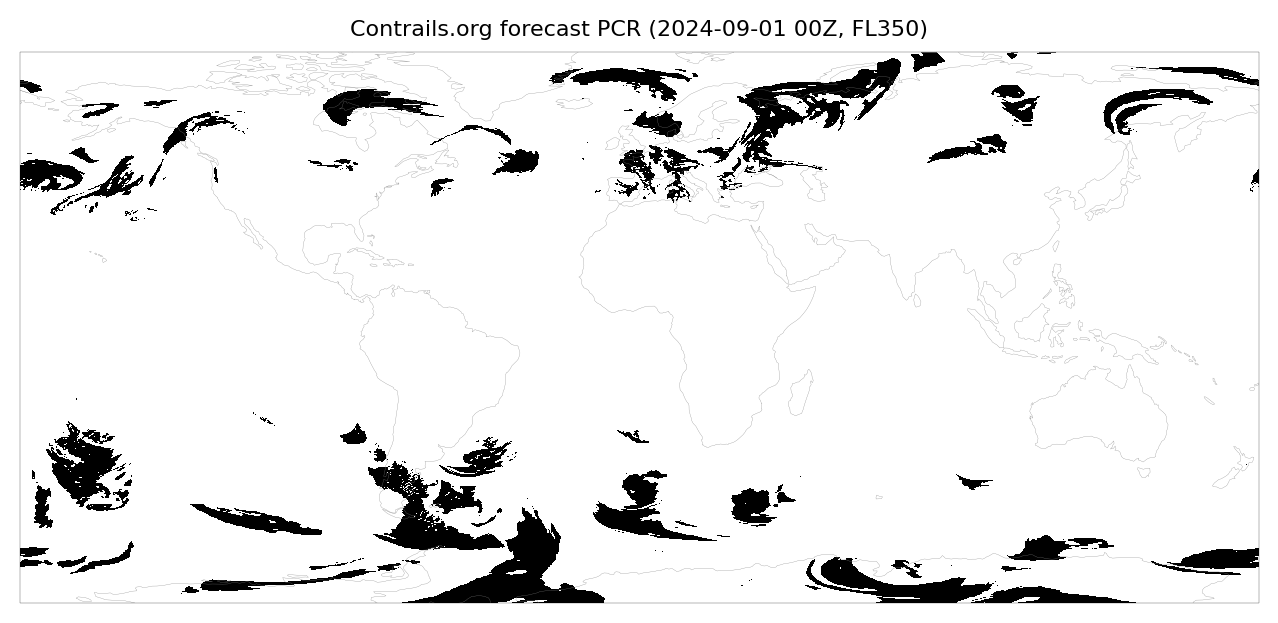

In [4]:
plt.figure(figsize=(6.5, 3), dpi=200, constrained_layout=True)
ax = plt.subplot(111, projection=ccrs.PlateCarree())
ax.pcolormesh(ds["longitude"], ds["latitude"], ds["pcr"].squeeze().T, cmap="Greys", shading="nearest")
ax.coastlines(color="gray", lw=0.1)
plt.setp(ax.spines.values(), linewidth=0.1)
ax.set_title(f"Contrails.org forecast PCR ({time.strftime('%Y-%m-%d %HZ')}, FL{flight_level})", fontsize=8)
ax.set_extent([-180, 180, -80, 80]);

# Google forecasts

In [5]:
with temp.temp_file() as tmp:
    fs.get(f"{bucket}/tmp/2025Q1/google/{int(time.timestamp())}_{flight_level}.nc", tmp)
    ds = xr.open_dataset(tmp)

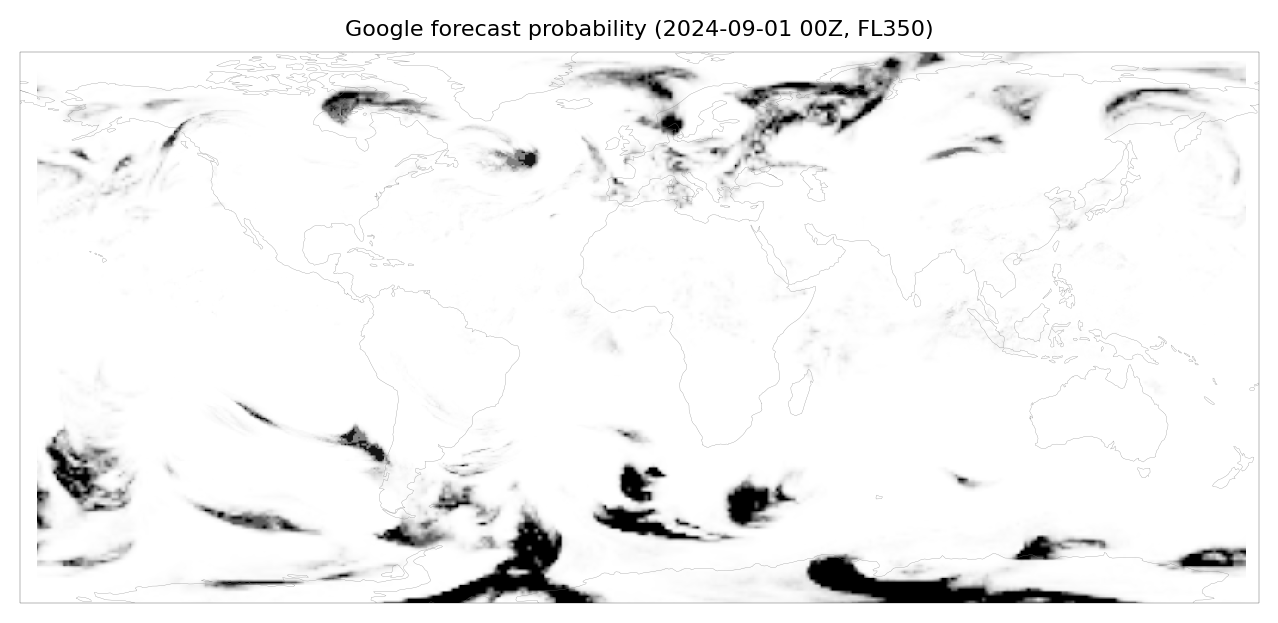

In [6]:
plt.figure(figsize=(6.5, 3), dpi=200, constrained_layout=True)
ax = plt.subplot(111, projection=ccrs.PlateCarree())
ax.pcolormesh(ds["longitude"], ds["latitude"], ds["ppcr"].squeeze().T, cmap="Greys", shading="nearest")
ax.coastlines(color="gray", lw=0.1)
plt.setp(ax.spines.values(), linewidth=0.1)
ax.set_title(f"Google forecast probability ({time.strftime('%Y-%m-%d %HZ')}, FL{flight_level})", fontsize=8)
ax.set_extent([-180, 180, -80, 80]);

# Download processed datasets

In [7]:
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-adsb .
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos .
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-gruan .
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-contrailwatch .

In [8]:
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-adsb .
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-iagos .
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-gruan .
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-contrailwatch .

# Helper functions, colors, etc

In [9]:
def open_dfs(path):
    """Open and concatenate all dataframes in directory."""
    df_list = [pd.read_parquet(f) for f in tqdm(sorted(glob.glob(f"{path}/*.pq")), desc=path)]
    return pd.concat(df_list, axis="index")

In [10]:
def penalty(df, grouping_key):
    """Compute flight distance penalty."""
    return df.groupby(grouping_key)[["adsb_dist_in_forecast_pcr", "adsb_dist"]].apply(
        lambda x: x["adsb_dist_in_forecast_pcr"].sum() / x["adsb_dist"].sum()
    )

In [11]:
def hit_rate(df, grouping_key):
    """Compute hit rate."""
    return df.groupby(grouping_key)[["observed_pcr_area_in_forecast_pcr", "observed_pcr_area"]].apply(
        lambda x: x["observed_pcr_area_in_forecast_pcr"].sum() / x["observed_pcr_area"].sum()
    )

In [12]:
exo_black = "#161a26"
tropo_blue = "#1093ff"
solar_orange = "#f26400"
gray50 = "#939598"

In [13]:
df = pd.read_parquet("gs://contrails-301217-iagos-v2/Processed/2024/waypoints.pq")

In [14]:
air_temperature = df["air_temperature"].values
specific_humidity = 1e-6 * df["h2o_gas_ppmv"].values * constants.R_d / constants.R_v
air_pressure = df["pressure"].values
G = sac.slope_mixing_line(specific_humidity, air_pressure, 0.3, JetA.ei_h2o, JetA.q_fuel)
T_sat_liquid_ = sac.T_sat_liquid(G)
rh_crit_sac = sac.rh_critical_sac(air_temperature, T_sat_liquid_, G)
rh = thermo.rh(specific_humidity, air_temperature, air_pressure)
rhi = thermo.rhi(specific_humidity, air_temperature, air_pressure)

pcr = (rh > rh_crit_sac) & (rhi > 1.0)
quality_mask = (
    (df["h2o_gas_validity_flag"] == 0) &
    (df["air_temperature_validity_flag"] == 0)
).values

df["pcr"] = pcr
df["quality_mask"] = quality_mask

In [15]:
iagos_pcr_rate = df["segment_length"].where(df["pcr"] & df["quality_mask"]).sum() / df["segment_length"].where(df["quality_mask"]).sum()

# Contrails.org forecast

In [16]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")
df_contrailwatch = open_dfs("contrails-org-contrailwatch")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-contrailwatch:   0%|          | 0/5880 [00:00<?, ?it/s]

In [17]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
    "contrailwatch_hit_rate": hit_rate(df_contrailwatch, "horizontal_buffer"),
})

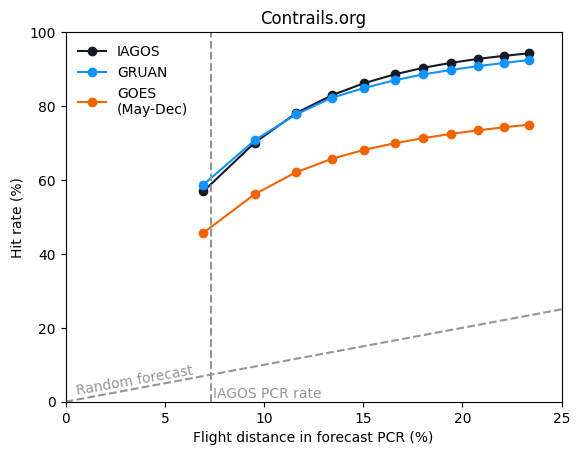

In [18]:
plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "-o", color=exo_black, label="IAGOS")
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate"], "-o", color=solar_orange, label="GOES\n(May-Dec)")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org");

# Contrails.org + Google forecasts (September only)

In [26]:
df_contrails_adsb = df_adsb[df_adsb["time"].between("2024-09-01 00:00", "2024-12-31 23:00")]
df_contrails_iagos = df_iagos[df_iagos["time"].between("2024-09-01 00:00", "2024-12-31 23:00")]
df_contrails_gruan = df_gruan[df_gruan["time"].between("2024-09-01 00:00", "2024-12-31 23:00")]
df_contrails_contrailwatch = df_contrailwatch[df_contrailwatch["time"].between("2024-09-01 00:00", "2024-12-31 23:00")]

In [27]:
df_contrails_org = pd.DataFrame({
    "penalty": penalty(df_contrails_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate(df_contrails_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate(df_contrails_gruan, "horizontal_buffer"),
    "contrailwatch_hit_rate": hit_rate(df_contrails_contrailwatch, "horizontal_buffer"),
})

In [28]:
df_google_adsb = open_dfs("google-adsb")
df_google_iagos = open_dfs("google-iagos")
df_google_gruan = open_dfs("google-gruan")
df_google_contrailwatch = open_dfs("google-contrailwatch")

google-adsb:   0%|          | 0/2928 [00:00<?, ?it/s]

google-iagos:   0%|          | 0/2928 [00:00<?, ?it/s]

google-gruan:   0%|          | 0/2928 [00:00<?, ?it/s]

google-contrailwatch:   0%|          | 0/2928 [00:00<?, ?it/s]

In [29]:
df_google = pd.DataFrame({
    "penalty": penalty(df_google_adsb, "probability_threshold"),
    "iagos_hit_rate": hit_rate(df_google_iagos, "probability_threshold"),
    "gruan_hit_rate": hit_rate(df_google_gruan, "probability_threshold"),
    "contrailwatch_hit_rate": hit_rate(df_google_contrailwatch, "probability_threshold"),
})

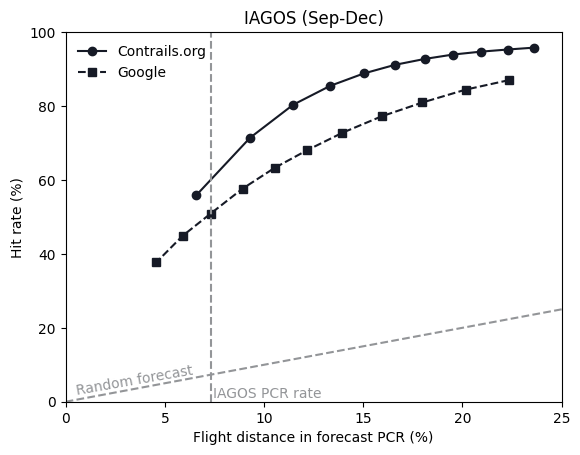

In [30]:
plt.plot(100 * df_contrails_org["penalty"], 100 * df_contrails_org["iagos_hit_rate"], "-o", color=exo_black, label="Contrails.org")
plt.plot(100 * df_google["penalty"], 100 * df_google["iagos_hit_rate"], "--s", color=exo_black, label="Google")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("IAGOS (Sep-Dec)");

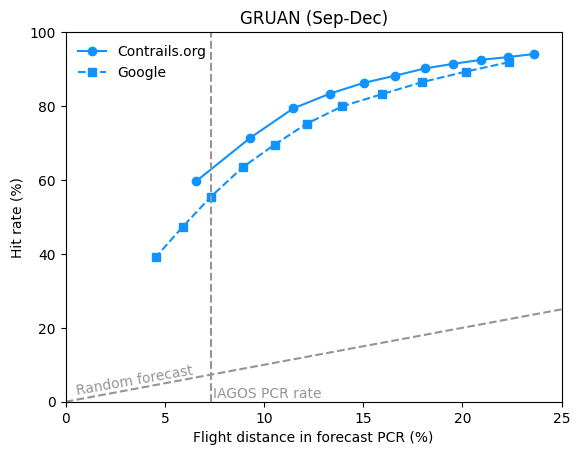

In [31]:
plt.plot(100 * df_contrails_org["penalty"], 100 * df_contrails_org["gruan_hit_rate"], "-o", color=tropo_blue, label="Contrails.org")
plt.plot(100 * df_google["penalty"], 100 * df_google["gruan_hit_rate"], "--s", color=tropo_blue, label="Google")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("GRUAN (Sep-Dec)");

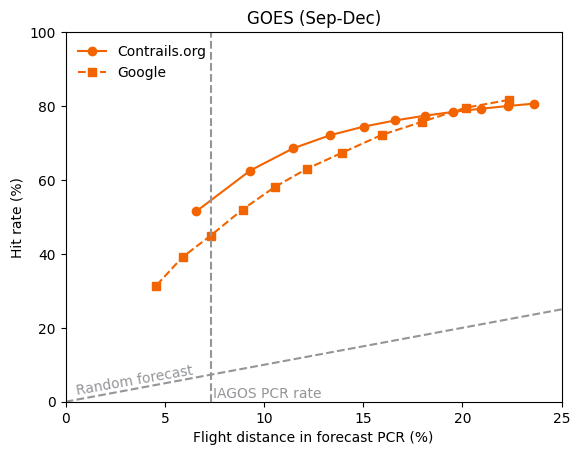

In [32]:
plt.plot(100 * df_contrails_org["penalty"], 100 * df_contrails_org["contrailwatch_hit_rate"], "-o", color=solar_orange, label="Contrails.org")
plt.plot(100 * df_google["penalty"], 100 * df_google["contrailwatch_hit_rate"], "--s", color=solar_orange, label="Google")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("GOES (Sep-Dec)");